EXP-10 Implementation of Clustering Algorithms (K-Means, K-Means++, Agglomerative, DBSCAN) using Scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

In [2]:
iris = load_iris()
X = iris.data[:, :2]  

In [3]:

# ---------------- K-MEANS ----------------
kmeans = KMeans(n_clusters=3, init='random')
kmeans.fit(X)

labels_kmeans = kmeans.labels_
print("K-Means Labels:\n", labels_kmeans)

K-Means Labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2
 0 0 0 0 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [4]:

# ---------------- K-MEANS++ ----------------
kmeans_pp = KMeans(n_clusters=3, init='k-means++')
kmeans_pp.fit(X)

labels_kmeans_pp = kmeans_pp.labels_
print("\nK-Means++ Labels:\n", labels_kmeans_pp)


K-Means++ Labels:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1
 2 2 2 2 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 2 0 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


In [5]:
# ---------------- AGGLOMERATIVE ----------------
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X)

print("\nAgglomerative Labels:\n", labels_agg)


Agglomerative Labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 1 0 1 1 0 2 0 2 0 2 2 2 2 0 0 2 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 1 2 2 2 0 1 2 0 2 0 0 0 0 1 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 0
 0 0]


In [6]:
# ---------------- DBSCAN ----------------
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X)

print("\nDBSCAN Labels:\n", labels_db)


DBSCAN Labels:
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0
  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]


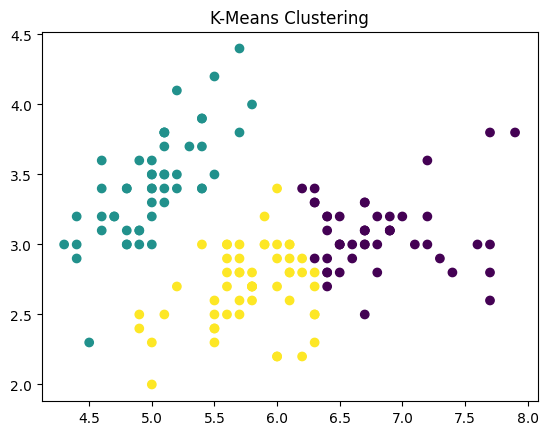

In [7]:
# ---------------- VISUALIZATION ----------------
# Plot K-Means clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.title("K-Means Clustering")
plt.show()

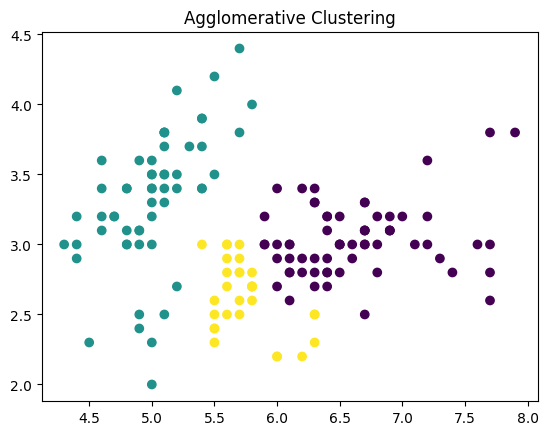

In [8]:
# Plot Agglomerative clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_agg)
plt.title("Agglomerative Clustering")
plt.show()

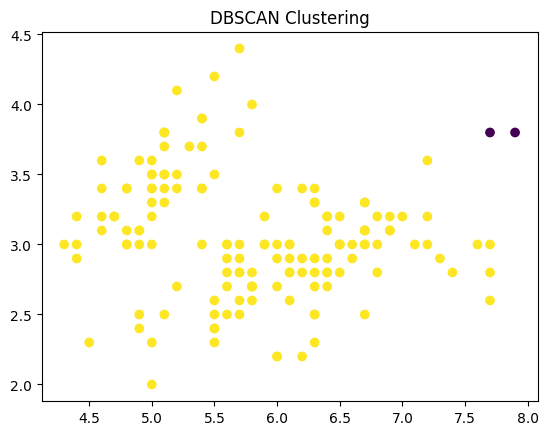

In [9]:
# Plot DBSCAN clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_db)
plt.title("DBSCAN Clustering")
plt.show()

In [1]:
from collections import deque

def water_jug_bfs(x, y, z):
    if z > max(x, y):
        return False
    
    visited = set()
    queue = deque([(0, 0)])

    while queue:
        a, b = queue.popleft()

        if (a, b) in visited:
            continue
        visited.add((a, b))

        if a == z or b == z:
            return True

        next_states = [
            (x, b),
            (a, y),
            (0, b),
            (a, 0),
            (a - min(a, y - b), b + min(a, y - b)),
            (a + min(b, x - a), b - min(b, x - a))
        ]

        for state in next_states:
            if state not in visited:
                queue.append(state)

    return False


# Input
x = 4
y = 3
z = 2

if water_jug_bfs(x, y, z):
    print("It is possible to measure", z, "liters.")
else:
    print("It is NOT possible.")

It is possible to measure 2 liters.


In [3]:
from queue import PriorityQueue

graph = {
    'A': [('B', 1), ('C', 3)],
    'B': [('D', 3), ('E', 1)],
    'C': [('F', 5)],
    'D': [],
    'E': [('F', 2)],
    'F': []
}

heuristic = {'A':6,'B':4,'C':5,'D':3,'E':2,'F':0}

def a_star(start, goal):
    pq = PriorityQueue()
    pq.put((0, start))
    
    parent = {start: None}
    cost = {start: 0}

    while not pq.empty():
        _, node = pq.get()

        print("Expanding:", node)

        if node == goal:
            break

        for neighbor, weight in graph[node]:
            new_cost = cost[node] + weight

            if neighbor not in cost or new_cost < cost[neighbor]:
                cost[neighbor] = new_cost
                priority = new_cost + heuristic[neighbor]
                pq.put((priority, neighbor))
                parent[neighbor] = node

    # Path reconstruction
    path = []
    node = goal
    while node:
        path.append(node)
        node = parent[node]
    path.reverse()

    return path, cost[goal]

path, cost = a_star('A','F')
print("Path:", path)
print("Cost:", cost)

Expanding: A
Expanding: B
Expanding: E
Expanding: F
Path: ['A', 'B', 'E', 'F']
Cost: 4


In [4]:
graph = {
    'A':[['B','C'],['D']],
    'B':[['E']],
    'C':[['F']],
    'D':[],
    'E':[],
    'F':[]
}

def ao(node):
    if node not in graph or not graph[node]:
        return node
    result = []
    for path in graph[node]:
        temp = []
        for n in path:
            temp.append(ao(n))
        result.append(temp)
    return result

print(ao('A'))

[[[['E']], [['F']]], ['D']]


In [5]:
def minimax(depth, index, isMax, scores, height):
    if depth == height:
        return scores[index]

    if isMax:
        return max(
            minimax(depth+1, index*2, False, scores, height),
            minimax(depth+1, index*2+1, False, scores, height)
        )
    else:
        return min(
            minimax(depth+1, index*2, True, scores, height),
            minimax(depth+1, index*2+1, True, scores, height)
        )

scores = [3,5,2,9,12,5,23,23]
print("Optimal Value:", minimax(0,0,True,scores,3))

Optimal Value: 12


In [6]:
from collections import deque

goal = [1,2,3,4,5,6,7,8,0]

def neighbors(state):
    i = state.index(0)
    moves = {0:[1,3],1:[0,2,4],2:[1,5],
             3:[0,4,6],4:[1,3,5,7],
             5:[2,4,8],6:[3,7],
             7:[4,6,8],8:[5,7]}
    result = []
    for m in moves[i]:
        new = state[:]
        new[i], new[m] = new[m], new[i]
        result.append(new)
    return result

def bfs(start):
    queue = deque([(start, [])])
    visited = []

    while queue:
        state, path = queue.popleft()
        if state == goal:
            return path + [state]

        visited.append(state)

        for n in neighbors(state):
            if n not in visited:
                queue.append((n, path+[state]))

sol = bfs([1,2,3,4,0,5,6,7,8])
for s in sol:
    print(s)

[1, 2, 3, 4, 0, 5, 6, 7, 8]
[1, 2, 3, 4, 5, 0, 6, 7, 8]
[1, 2, 3, 4, 5, 8, 6, 7, 0]
[1, 2, 3, 4, 5, 8, 6, 0, 7]
[1, 2, 3, 4, 5, 8, 0, 6, 7]
[1, 2, 3, 0, 5, 8, 4, 6, 7]
[1, 2, 3, 5, 0, 8, 4, 6, 7]
[1, 2, 3, 5, 6, 8, 4, 0, 7]
[1, 2, 3, 5, 6, 8, 4, 7, 0]
[1, 2, 3, 5, 6, 0, 4, 7, 8]
[1, 2, 3, 5, 0, 6, 4, 7, 8]
[1, 2, 3, 0, 5, 6, 4, 7, 8]
[1, 2, 3, 4, 5, 6, 0, 7, 8]
[1, 2, 3, 4, 5, 6, 7, 0, 8]
[1, 2, 3, 4, 5, 6, 7, 8, 0]


In [7]:
graph = {
    'A':['B','C'],
    'B':['D','E'],
    'C':['F'],
    'D':[],'E':[],'F':[]
}

def dls(node, goal, depth, path):
    if depth == 0 and node == goal:
        return path+[node]

    if depth > 0:
        for child in graph[node]:
            result = dls(child, goal, depth-1, path+[node])
            if result:
                return result
    return None

def iddfs(start, goal, max_depth):
    for d in range(max_depth):
        res = dls(start, goal, d, [])
        if res:
            return res

print(iddfs('A','F',3))

['A', 'C', 'F']
